# 11_resnet18_lstm

Unified ResNet18 + LSTM compression experiment.

## Main idea
For each training compression level:
- build short temporal clips from that level's train split
- train on that level's train split
- validate on that level's val split
- save the best checkpoint
- test on all compression levels

## Compression levels
- orig
- CRF18
- CRF23
- CRF28
- CRF35
- CRF51

## Model
- ResNet18 frame encoder
- LSTM temporal model
- clip-level classification using the last time step

## Outputs
Saved under:
- `cholec80/outputs/resnet18_lstm/checkpoints/`
- `cholec80/outputs/resnet18_lstm/predictions/`
- `cholec80/outputs/resnet18_lstm/metrics/`
- `cholec80/outputs/resnet18_lstm/plots/`
- `cholec80/outputs/resnet18_lstm/gradcam/`

In [1]:
# ============================================================
# 1. Imports
# ============================================================
import json
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from tqdm.auto import tqdm

In [2]:
# ============================================================
# 2. Reproducibility and device
# ============================================================
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        try:
            torch.mps.manual_seed(seed)
        except Exception:
            pass

set_seed(SEED)

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: mps


In [3]:
# ============================================================
# 3. Paths
# ============================================================
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "cholec80"
FRAME_PREP_DIR = DATA_ROOT / "outputs" / "frame_prep"

MODEL_OUT_DIR = DATA_ROOT / "outputs" / "resnet18_lstm"
CHECKPOINT_DIR = MODEL_OUT_DIR / "checkpoints"
PREDICTIONS_DIR = MODEL_OUT_DIR / "predictions"
METRICS_DIR = MODEL_OUT_DIR / "metrics"
PLOTS_DIR = MODEL_OUT_DIR / "plots"
GRADCAM_DIR = MODEL_OUT_DIR / "gradcam"

for p in [CHECKPOINT_DIR, PREDICTIONS_DIR, METRICS_DIR, PLOTS_DIR, GRADCAM_DIR]:
    p.mkdir(parents=True, exist_ok=True)

METADATA_PATHS = {
    "orig": FRAME_PREP_DIR / "pilot_metadata_orig.csv",
    "CRF18": FRAME_PREP_DIR / "pilot_metadata_CRF18.csv",
    "CRF23": FRAME_PREP_DIR / "pilot_metadata_CRF23.csv",
    "CRF28": FRAME_PREP_DIR / "pilot_metadata_CRF28.csv",
    "CRF35": FRAME_PREP_DIR / "pilot_metadata_CRF35.csv",
    "CRF51": FRAME_PREP_DIR / "pilot_metadata_CRF51.csv",
}

In [4]:
# ============================================================
# 4. Config
# ============================================================
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 0
EPOCHS = 5
LR = 1e-4
WEIGHT_DECAY = 5e-4
DROPOUT_P = 0.3

CLIP_LEN = 8
FRAME_STRIDE = 1

LSTM_HIDDEN_DIM = 256
LSTM_NUM_LAYERS = 1
BIDIRECTIONAL = False

PHASE_MAP = {
    "Preparation": 0,
    "CalotTriangleDissection": 1,
    "ClippingCutting": 2,
    "GallbladderDissection": 3,
    "GallbladderPackaging": 4,
    "CleaningCoagulation": 5,
    "GallbladderRetraction": 6,
}
ID_TO_PHASE = {v: k for k, v in PHASE_MAP.items()}
NUM_CLASSES = len(PHASE_MAP)

LEVELS = ["orig", "CRF18", "CRF23", "CRF28", "CRF35", "CRF51"]
CRF_X = [0, 18, 23, 28, 35, 51]
LEVEL_TO_X = dict(zip(LEVELS, CRF_X))

In [5]:
# ============================================================
# 5. Load metadata
# ============================================================
metadata = {}

for level, path in METADATA_PATHS.items():
    df = pd.read_csv(path)
    df = df[df["image_exists"] == True].copy().reset_index(drop=True)
    metadata[level] = df
    print(level, df.shape)

orig (46099, 9)
CRF18 (46099, 9)
CRF23 (46099, 9)
CRF28 (46099, 9)
CRF35 (46099, 9)
CRF51 (46099, 9)


In [6]:
# ============================================================
# 6. Transforms
# ============================================================
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

## Build temporal clips

Each sample is a causal clip ending at a center frame:
- length = `CLIP_LEN`
- stride = `FRAME_STRIDE`
- label = phase at the center / last frame

In [7]:
# ============================================================
# 7. Build sequence samples
# ============================================================
def build_sequence_samples(df, clip_len=CLIP_LEN, frame_stride=FRAME_STRIDE):
    seq_rows = []

    for video, group in df.groupby("video"):
        group = group.sort_values("second_idx").reset_index(drop=True)
        by_second = {int(r["second_idx"]): r for _, r in group.iterrows()}

        valid_seconds = sorted(by_second.keys())

        for center_second in valid_seconds:
            start_second = center_second - (clip_len - 1) * frame_stride
            clip_seconds = [start_second + k * frame_stride for k in range(clip_len)]

            if not all(s in by_second for s in clip_seconds):
                continue

            clip_rows = [by_second[s] for s in clip_seconds]
            center_row = by_second[center_second]

            seq_rows.append({
                "compression": center_row["compression"],
                "video": center_row["video"],
                "split": center_row["split"],
                "center_second_idx": int(center_row["second_idx"]),
                "center_frame_idx": int(center_row["frame_idx"]),
                "phase_name": center_row["phase_name"],
                "phase_id": int(center_row["phase_id"]),
                "clip_image_paths": [r["image_path"] for r in clip_rows],
                "clip_second_idxs": clip_seconds,
                "center_image_path": center_row["image_path"],
            })

    return pd.DataFrame(seq_rows)


In [8]:
# ============================================================
# 8. Sequence dataset
# ============================================================
class CholecSequenceDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        frames = []
        for p in row["clip_image_paths"]:
            img = Image.open(p).convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
            frames.append(img)

        frames = torch.stack(frames, dim=0)  # [T, C, H, W]
        label = int(row["phase_id"])

        meta = {
            "compression": row["compression"],
            "video": row["video"],
            "split": row["split"],
            "center_second_idx": int(row["center_second_idx"]),
            "center_frame_idx": int(row["center_frame_idx"]),
            "phase_name": row["phase_name"],
            "center_image_path": row["center_image_path"],
        }

        return frames, label, meta

In [9]:
# ============================================================
# 9. DataLoader builder
# ============================================================
def make_loaders_for_train_level(train_level):
    train_base = metadata[train_level][metadata[train_level]["split"] == "train"].reset_index(drop=True)
    val_base = metadata[train_level][metadata[train_level]["split"] == "val"].reset_index(drop=True)

    train_df = build_sequence_samples(train_base, clip_len=CLIP_LEN, frame_stride=FRAME_STRIDE)
    val_df = build_sequence_samples(val_base, clip_len=CLIP_LEN, frame_stride=FRAME_STRIDE)

    class_counts = train_df["phase_id"].value_counts().sort_index().to_dict()
    weights_per_class = {cls: 1.0 / count for cls, count in class_counts.items()}
    sample_weights = train_df["phase_id"].map(weights_per_class).values

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )

    train_loader = DataLoader(
        CholecSequenceDataset(train_df, transform=train_tfms),
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )

    val_loader = DataLoader(
        CholecSequenceDataset(val_df, transform=eval_tfms),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )

    test_loaders = {}
    test_sequence_dfs = {}

    for test_level in LEVELS:
        test_base = metadata[test_level][metadata[test_level]["split"] == "test"].reset_index(drop=True)
        test_df = build_sequence_samples(test_base, clip_len=CLIP_LEN, frame_stride=FRAME_STRIDE)
        test_sequence_dfs[test_level] = test_df

        test_loaders[test_level] = DataLoader(
            CholecSequenceDataset(test_df, transform=eval_tfms),
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=False,
        )

    return train_df, val_df, train_loader, val_loader, test_sequence_dfs, test_loaders

In [10]:
# ============================================================
# 10. Sanity check one train level
# ============================================================
train_df_check, val_df_check, *_ = make_loaders_for_train_level("orig")
print("orig train sequences:", train_df_check.shape)
print("orig val sequences:", val_df_check.shape)
train_df_check.head()

orig train sequences: (26886, 10)
orig val sequences: (9027, 10)


,compression,video,split,center_second_idx,center_frame_idx,phase_name,phase_id,clip_image_paths,clip_second_idxs,center_image_path
0,orig,video01,train,7,175,Preparation,0,[/Users/niranjani/Desktop/video-compression-pr...,"[0, 1, 2, 3, 4, 5, 6, 7]",/Users/niranjani/Desktop/video-compression-pro...
1,orig,video01,train,8,200,Preparation,0,[/Users/niranjani/Desktop/video-compression-pr...,"[1, 2, 3, 4, 5, 6, 7, 8]",/Users/niranjani/Desktop/video-compression-pro...
2,orig,video01,train,9,225,Preparation,0,[/Users/niranjani/Desktop/video-compression-pr...,"[2, 3, 4, 5, 6, 7, 8, 9]",/Users/niranjani/Desktop/video-compression-pro...
3,orig,video01,train,10,250,Preparation,0,[/Users/niranjani/Desktop/video-compression-pr...,"[3, 4, 5, 6, 7, 8, 9, 10]",/Users/niranjani/Desktop/video-compression-pro...
4,orig,video01,train,11,275,Preparation,0,[/Users/niranjani/Desktop/video-compression-pr...,"[4, 5, 6, 7, 8, 9, 10, 11]",/Users/niranjani/Desktop/video-compression-pro...


## Model: ResNet18 encoder + LSTM

In [11]:
# ============================================================
# 11. Model
# ============================================================
class ResNet18LSTM(nn.Module):
    def __init__(
        self,
        num_classes=NUM_CLASSES,
        hidden_dim=LSTM_HIDDEN_DIM,
        num_layers=LSTM_NUM_LAYERS,
        dropout_p=DROPOUT_P,
        bidirectional=BIDIRECTIONAL,
    ):
        super().__init__()

        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])  # [B, 512, 1, 1]
        self.feature_dim = 512

        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout_p,
            bidirectional=bidirectional,
        )

        lstm_out_dim = hidden_dim * (2 if bidirectional else 1)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout_p),
            nn.Linear(lstm_out_dim, num_classes),
        )

    def forward(self, x):
        # x: [B, T, C, H, W]
        B, T, C, H, W = x.shape

        x = x.view(B * T, C, H, W)
        feats = self.encoder(x)                # [B*T, 512, 1, 1]
        feats = feats.view(B * T, self.feature_dim)
        feats = feats.view(B, T, self.feature_dim)

        lstm_out, _ = self.lstm(feats)         # [B, T, H]
        last_out = lstm_out[:, -1, :]
        logits = self.classifier(last_out)
        return logits

In [12]:
# ============================================================
# 12. Training / evaluation helpers
# ============================================================
def run_epoch(model, loader, criterion, optimizer=None, train=False):
    model.train() if train else model.eval()

    total_loss = 0.0
    all_y = []
    all_pred = []
    all_prob = []
    all_meta = []

    for clips, labels, metas in tqdm(loader, leave=False):
        clips = clips.to(DEVICE)   # [B, T, C, H, W]
        labels = labels.to(DEVICE)

        with torch.set_grad_enabled(train):
            logits = model(clips)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * clips.size(0)
        preds = torch.argmax(probs, dim=1)

        all_y.extend(labels.detach().cpu().numpy().tolist())
        all_pred.extend(preds.detach().cpu().numpy().tolist())
        all_prob.extend(probs.detach().cpu().numpy())

        for i in range(len(labels)):
            meta = {
                k: metas[k][i] if isinstance(metas[k], list) else metas[k][i]
                for k in metas
            }
            all_meta.append(meta)

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_y), np.array(all_pred), np.array(all_prob), all_meta


def multiclass_metrics(y_true, y_pred, y_prob, num_classes=NUM_CLASSES):
    acc = accuracy_score(y_true, y_pred)

    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    prec_per, rec_per, f1_per, support_per = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=None,
        labels=list(range(num_classes)),
        zero_division=0,
    )

    y_true_onehot = np.eye(num_classes)[y_true]

    try:
        auc_macro = roc_auc_score(
            y_true_onehot, y_prob, average="macro", multi_class="ovr"
        )
    except Exception:
        auc_macro = np.nan

    return {
        "accuracy": float(acc),
        "precision_macro": float(prec_macro),
        "recall_macro": float(rec_macro),
        "f1_macro": float(f1_macro),
        "auc_macro_ovr": None if np.isnan(auc_macro) else float(auc_macro),
        "per_class_f1": {ID_TO_PHASE[i]: float(f1_per[i]) for i in range(num_classes)},
        "per_class_precision": {ID_TO_PHASE[i]: float(prec_per[i]) for i in range(num_classes)},
        "per_class_recall": {ID_TO_PHASE[i]: float(rec_per[i]) for i in range(num_classes)},
        "support": {ID_TO_PHASE[i]: int(support_per[i]) for i in range(num_classes)},
    }


def save_prediction_table(y_true, y_pred, y_prob, metas, save_path):
    rows = []
    for i in range(len(y_true)):
        row = dict(metas[i])
        row["y_true"] = int(y_true[i])
        row["y_pred"] = int(y_pred[i])
        row["y_true_name"] = ID_TO_PHASE[int(y_true[i])]
        row["y_pred_name"] = ID_TO_PHASE[int(y_pred[i])]

        for c in range(NUM_CLASSES):
            row[f"prob_{ID_TO_PHASE[c]}"] = float(y_prob[i, c])

        rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(save_path, index=False)
    return df

In [13]:
# ============================================================
# 13. Cross-compression experiment
# ============================================================
all_results = {}
all_history = []
all_pred_tables = {}

for train_level in LEVELS:
    print("\n" + "=" * 70)
    print(f"TRAIN LEVEL: {train_level}")
    print("=" * 70)

    train_df, val_df, train_loader, val_loader, test_sequence_dfs, test_loaders = make_loaders_for_train_level(train_level)

    model = ResNet18LSTM().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )

    checkpoint_path = CHECKPOINT_DIR / f"best_resnet18_lstm_train_{train_level}.pth"

    best_val_f1 = -1.0
    train_level_history = []

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_y, train_pred, train_prob, train_meta = run_epoch(
            model, train_loader, criterion, optimizer=optimizer, train=True
        )

        val_loss, val_y, val_pred, val_prob, val_meta = run_epoch(
            model, val_loader, criterion, optimizer=None, train=False
        )

        train_metrics = multiclass_metrics(train_y, train_pred, train_prob)
        val_metrics = multiclass_metrics(val_y, val_pred, val_prob)

        scheduler.step(val_metrics["f1_macro"])

        row = {
            "train_level": train_level,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_metrics["accuracy"],
            "val_acc": val_metrics["accuracy"],
            "train_precision_macro": train_metrics["precision_macro"],
            "val_precision_macro": val_metrics["precision_macro"],
            "train_recall_macro": train_metrics["recall_macro"],
            "val_recall_macro": val_metrics["recall_macro"],
            "train_f1_macro": train_metrics["f1_macro"],
            "val_f1_macro": val_metrics["f1_macro"],
        }
        train_level_history.append(row)
        all_history.append(row)

        print(
            f"[{train_level}] Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
            f"train_f1={train_metrics['f1_macro']:.4f} val_f1={val_metrics['f1_macro']:.4f} | "
            f"train_acc={train_metrics['accuracy']:.4f} val_acc={val_metrics['accuracy']:.4f}"
        )

        if val_metrics["f1_macro"] > best_val_f1:
            best_val_f1 = val_metrics["f1_macro"]
            torch.save({
                "train_level": train_level,
                "model_state_dict": copy.deepcopy(model.state_dict()),
                "best_val_f1": best_val_f1,
                "epoch": epoch,
                "history": train_level_history,
            }, checkpoint_path)
            print("Saved best checkpoint:", checkpoint_path)

    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    for test_level in LEVELS:
        print(f"Evaluating train={train_level} -> test={test_level}")

        loss, y_true, y_pred, y_prob, metas = run_epoch(
            model, test_loaders[test_level], criterion, optimizer=None, train=False
        )

        metrics = multiclass_metrics(y_true, y_pred, y_prob)
        metrics["loss"] = float(loss)
        metrics["train_level"] = train_level
        metrics["test_level"] = test_level

        pred_path = PREDICTIONS_DIR / f"train_{train_level}__test_{test_level}.csv"
        pred_df = save_prediction_table(y_true, y_pred, y_prob, metas, pred_path)

        all_results[(train_level, test_level)] = metrics
        all_pred_tables[(train_level, test_level)] = pred_df


TRAIN LEVEL: orig


  0%|          | 0/3361 [00:00<?, ?it/s]

  0%|          | 0/1129 [00:00<?, ?it/s]

[orig] Epoch 01 | train_loss=0.2608 val_loss=1.4077 | train_f1=0.9168 val_f1=0.5048 | train_acc=0.9169 val_acc=0.6370
Saved best checkpoint: /Users/niranjani/Desktop/video-compression-project/cholec80/outputs/resnet18_lstm/checkpoints/best_resnet18_lstm_train_orig.pth


  0%|          | 0/3361 [00:00<?, ?it/s]

...

  0%|          | 0/1256 [00:00<?, ?it/s]

Evaluating train=CRF51 -> test=CRF35


  0%|          | 0/1256 [00:00<?, ?it/s]

Evaluating train=CRF51 -> test=CRF51


  0%|          | 0/1256 [00:00<?, ?it/s]

In [14]:
# ============================================================
# 14. Save long-form results
# ============================================================
history_df = pd.DataFrame(all_history)
history_df.to_csv(METRICS_DIR / "training_history_all_train_levels.csv", index=False)

result_rows = []
for (train_level, test_level), m in all_results.items():
    result_rows.append({
        "train_level": train_level,
        "test_level": test_level,
        "accuracy": m["accuracy"],
        "precision_macro": m["precision_macro"],
        "recall_macro": m["recall_macro"],
        "f1_macro": m["f1_macro"],
        "auc_macro_ovr": m["auc_macro_ovr"],
        "loss": m["loss"],
    })

results_df = pd.DataFrame(result_rows).sort_values(["train_level", "test_level"]).reset_index(drop=True)
results_df.to_csv(METRICS_DIR / "cross_compression_metrics.csv", index=False)

with open(METRICS_DIR / "cross_compression_metrics.json", "w") as f:
    json.dump(result_rows, f, indent=2)

results_df

,train_level,test_level,accuracy,precision_macro,recall_macro,f1_macro,auc_macro_ovr,loss
0,CRF18,CRF18,0.761597,0.657726,0.728318,0.680977,0.938042,0.998143
1,CRF18,CRF23,0.761995,0.658364,0.731402,0.682601,0.937808,0.999656
2,CRF18,CRF28,0.761398,0.656472,0.726403,0.679373,0.937417,0.997442
3,CRF18,CRF35,0.745371,0.642592,0.710050,0.662271,0.931648,1.058981
4,CRF18,CRF51,0.474816,0.503478,0.453903,0.371350,0.820311,2.495992
5,CRF18,orig,0.762791,0.658969,0.729326,0.682113,0.938239,0.995739
6,CRF23,CRF18,0.774438,0.658998,0.691632,0.669294,0.935254,0.911543
7,CRF23,CRF23,0.774637,0.656906,0.691780,0.668059,0.934948,0.909337
8,CRF23,CRF28,0.775732,0.657951,0.695291,0.670396,0.934498,0.912082
9,CRF23,CRF35,0.766076,0.654560,0.696316,0.669096,0.930544,0.948718


In [15]:
# ============================================================
# 15. Pivot tables
# ============================================================
pivot_acc = results_df.pivot(index="train_level", columns="test_level", values="accuracy").loc[LEVELS, LEVELS]
pivot_prec = results_df.pivot(index="train_level", columns="test_level", values="precision_macro").loc[LEVELS, LEVELS]
pivot_f1 = results_df.pivot(index="train_level", columns="test_level", values="f1_macro").loc[LEVELS, LEVELS]
pivot_auc = results_df.pivot(index="train_level", columns="test_level", values="auc_macro_ovr").loc[LEVELS, LEVELS]

display(pivot_f1)

test_level,orig,CRF18,CRF23,CRF28,CRF35,CRF51
train_level,,,,,,
orig,0.688480,0.687497,0.685919,0.679565,0.677493,0.382898
CRF18,0.682113,0.680977,0.682601,0.679373,0.662271,0.371350
CRF23,0.668443,0.669294,0.668059,0.670396,0.669096,0.494293
CRF28,0.714914,0.712461,0.714204,0.712230,0.703308,0.535429
CRF35,0.656625,0.658465,0.655515,0.659875,0.655316,0.464306
CRF51,0.630608,0.629488,0.628346,0.631617,0.624698,0.662270


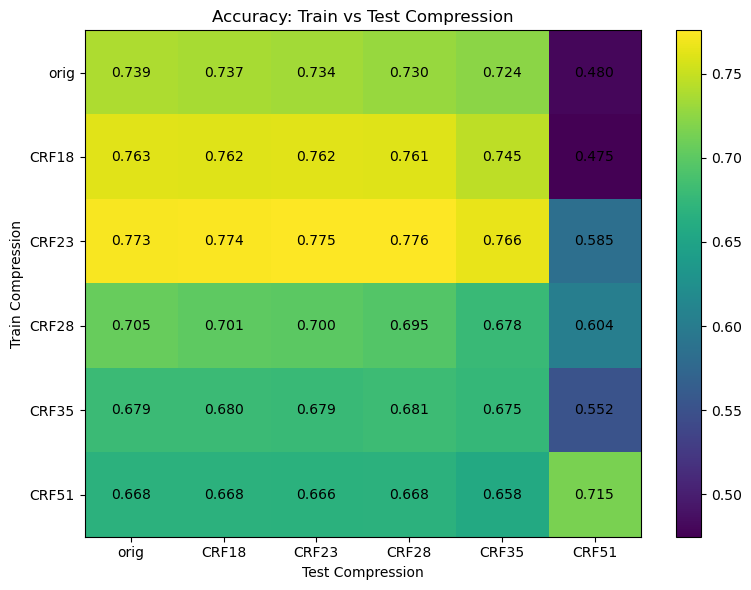

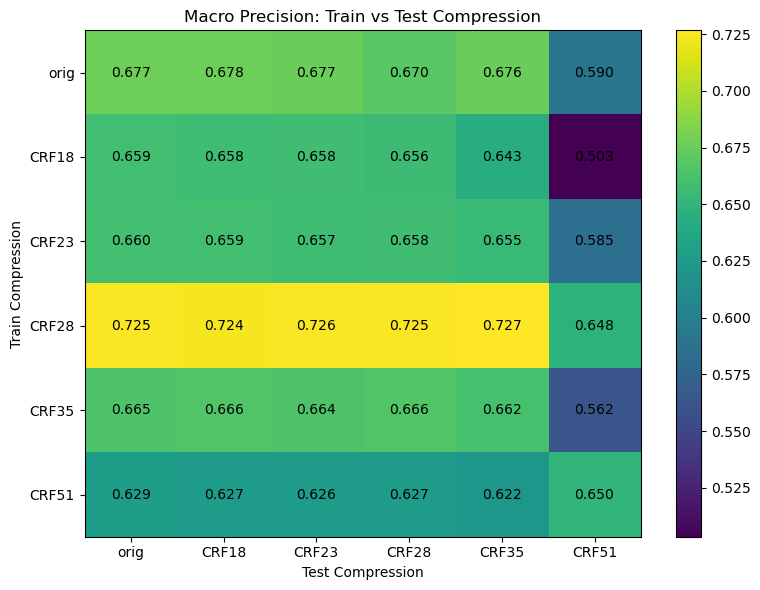

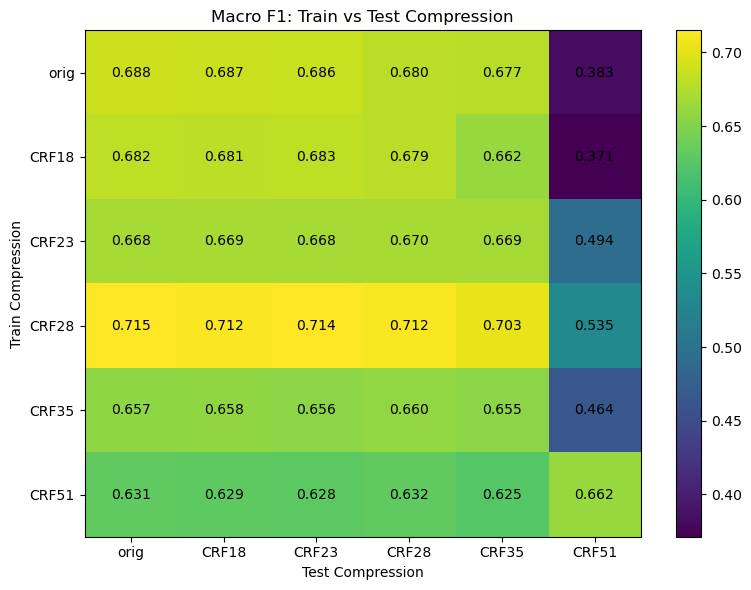

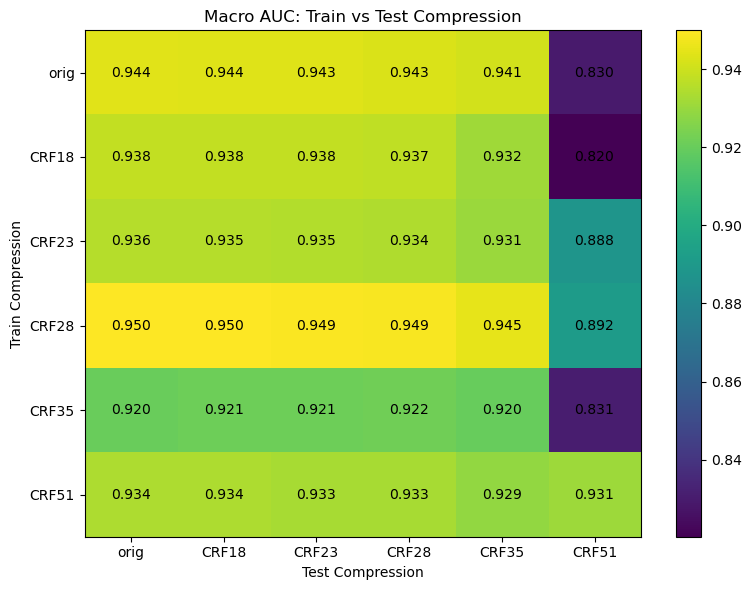

In [16]:
# ============================================================
# 16. Heatmap helper
# ============================================================
def plot_heatmap(df, title, save_name, vmin=None, vmax=None):
    arr = df.values

    plt.figure(figsize=(8, 6))
    im = plt.imshow(arr, aspect="auto", vmin=vmin, vmax=vmax)
    plt.colorbar(im)

    plt.xticks(range(len(df.columns)), df.columns)
    plt.yticks(range(len(df.index)), df.index)
    plt.xlabel("Test Compression")
    plt.ylabel("Train Compression")
    plt.title(title)

    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            val = arr[i, j]
            if pd.notna(val):
                plt.text(j, i, f"{val:.3f}", ha="center", va="center")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / save_name, dpi=200)
    plt.show()

plot_heatmap(pivot_acc, "Accuracy: Train vs Test Compression", "heatmap_accuracy.png")
plot_heatmap(pivot_prec, "Macro Precision: Train vs Test Compression", "heatmap_precision.png")
plot_heatmap(pivot_f1, "Macro F1: Train vs Test Compression", "heatmap_f1.png")
plot_heatmap(pivot_auc, "Macro AUC: Train vs Test Compression", "heatmap_auc.png")

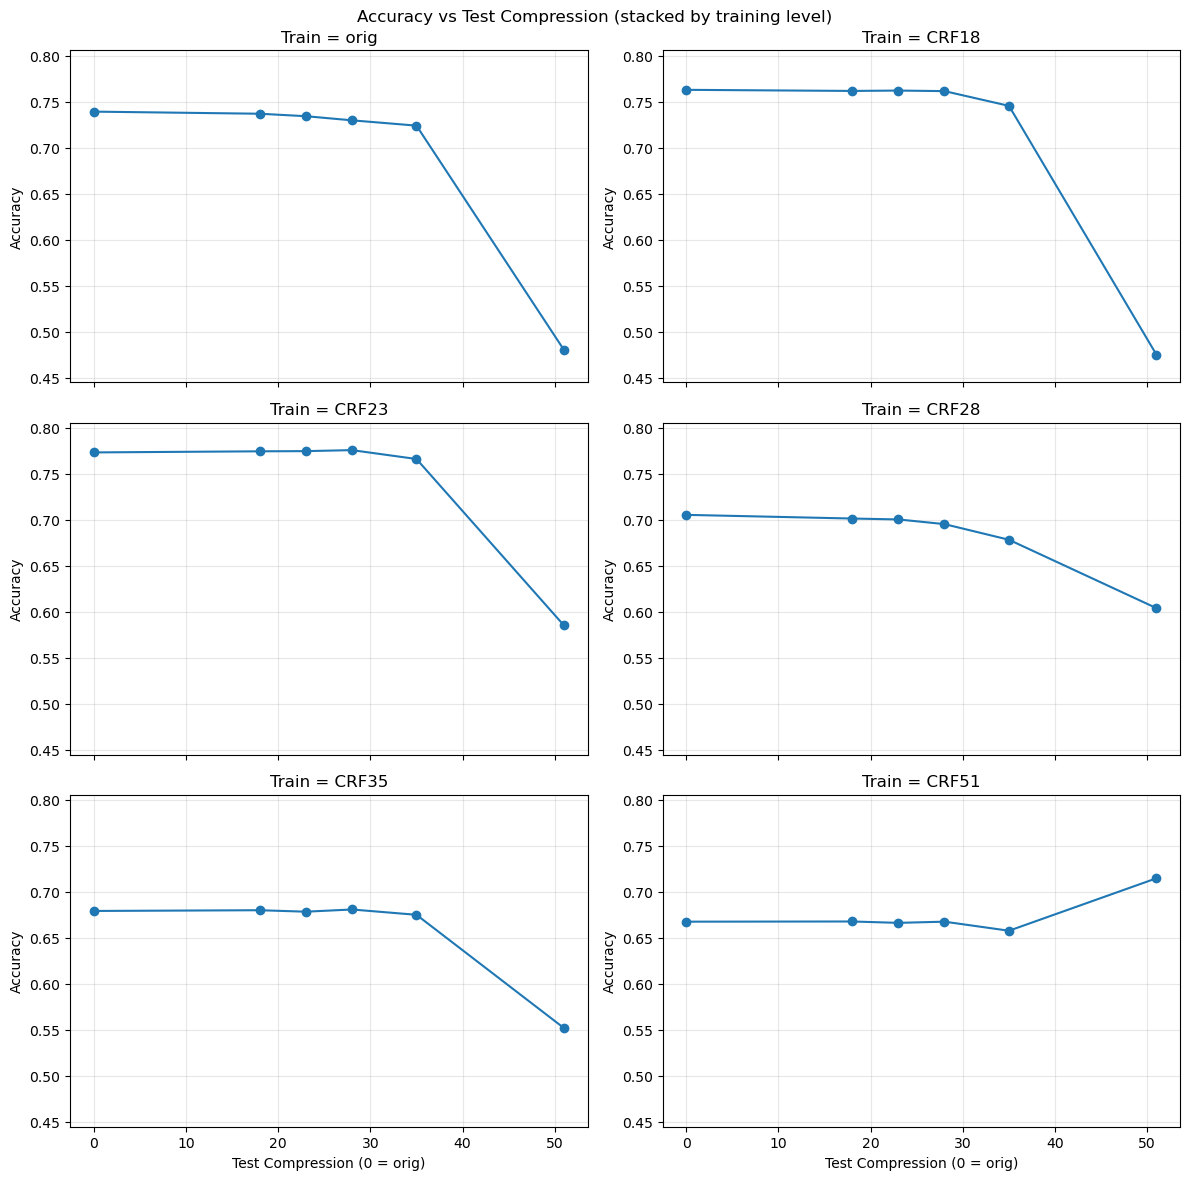

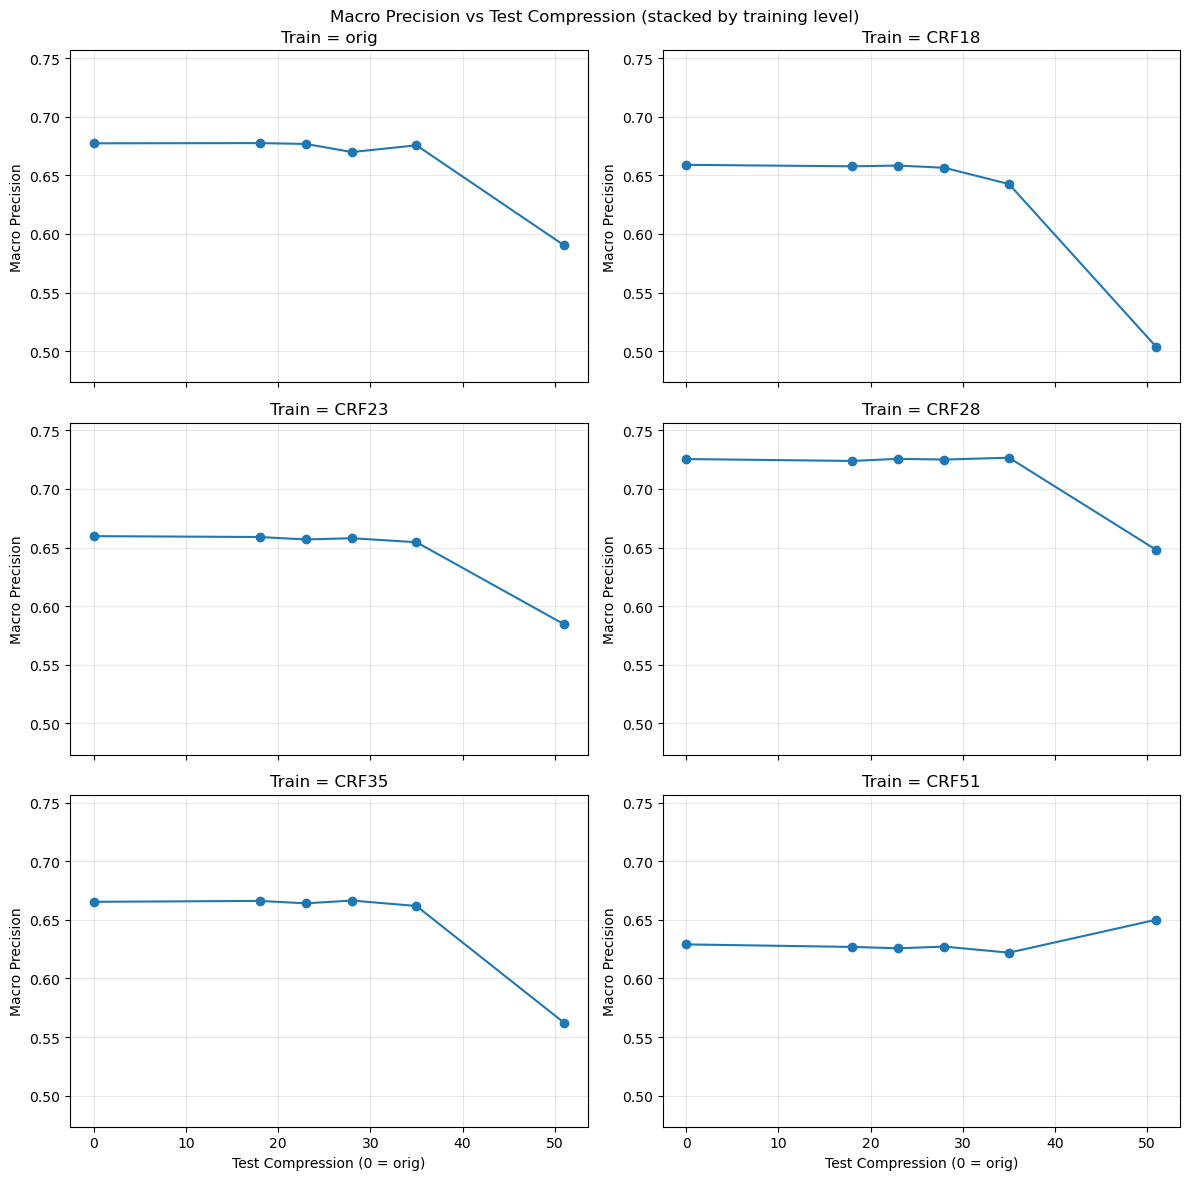

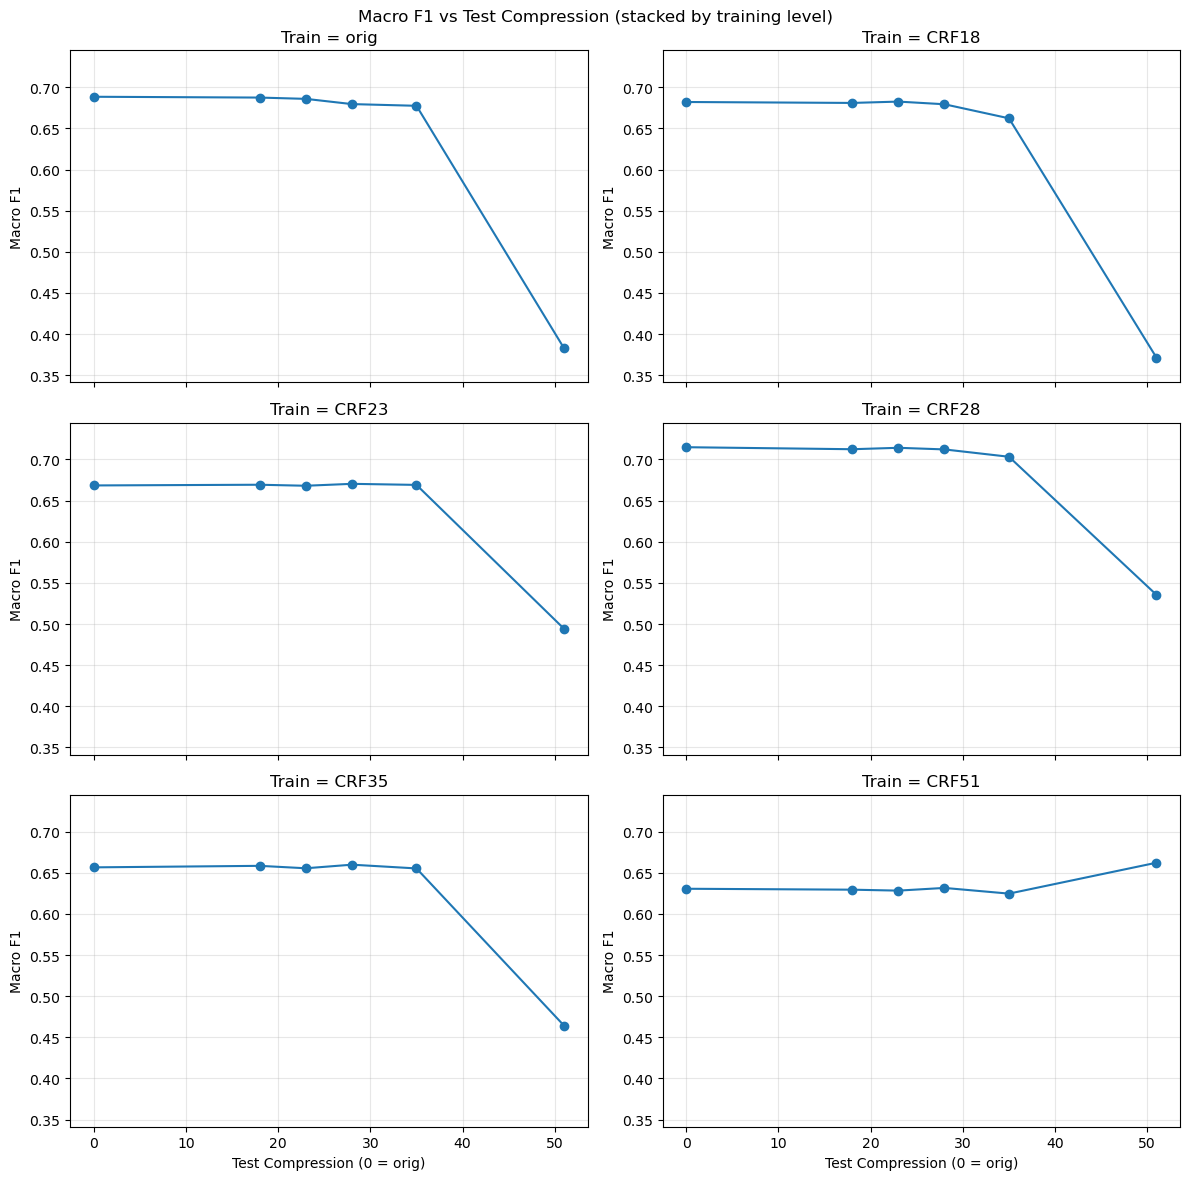

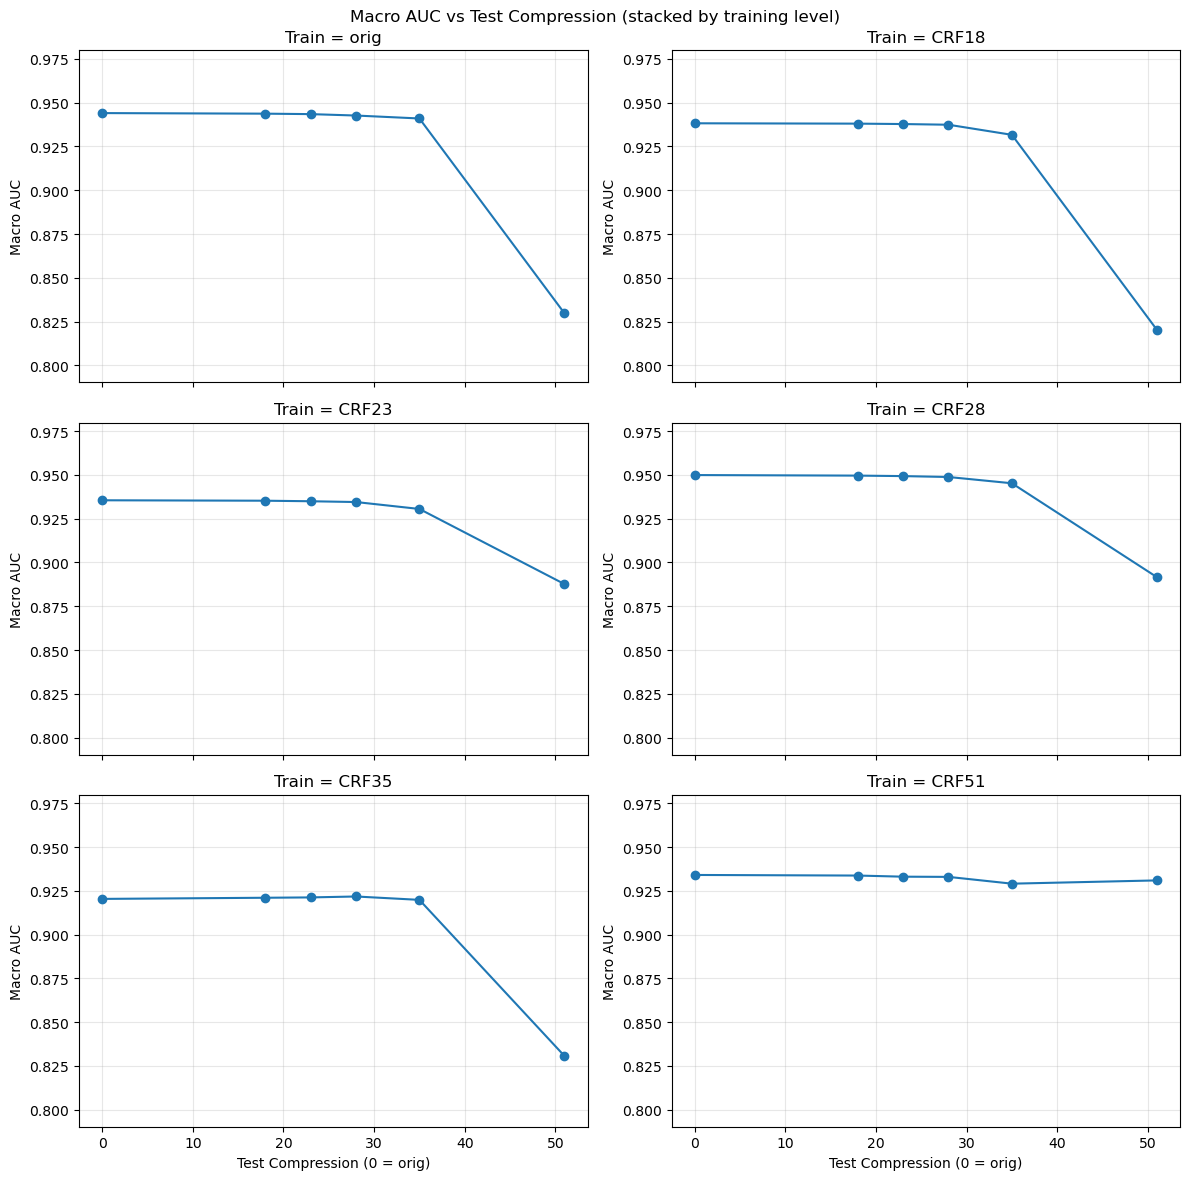

In [17]:
# ============================================================
# 17. Stacked metric-vs-test-compression plots
# ============================================================
def stacked_metric_plot(metric_name, y_label, save_name):
    fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=True)
    axes = axes.flatten()

    y_min = results_df[metric_name].min()
    y_max = results_df[metric_name].max()
    pad = 0.03

    for ax, train_level in zip(axes, LEVELS):
        subset = results_df[results_df["train_level"] == train_level].copy()
        subset["x"] = subset["test_level"].map(LEVEL_TO_X)
        subset = subset.sort_values("x")

        ax.plot(subset["x"], subset[metric_name], marker="o")
        ax.set_title(f"Train = {train_level}")
        ax.set_ylabel(y_label)
        ax.set_ylim(max(0, y_min - pad), min(1.0, y_max + pad))
        ax.grid(True, alpha=0.3)

    for ax in axes[-2:]:
        ax.set_xlabel("Test Compression (0 = orig)")

    plt.suptitle(f"{y_label} vs Test Compression (stacked by training level)")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / save_name, dpi=200)
    plt.show()

stacked_metric_plot("accuracy", "Accuracy", "stacked_accuracy_vs_test_compression.png")
stacked_metric_plot("precision_macro", "Macro Precision", "stacked_precision_vs_test_compression.png")
stacked_metric_plot("f1_macro", "Macro F1", "stacked_f1_vs_test_compression.png")
stacked_metric_plot("auc_macro_ovr", "Macro AUC", "stacked_auc_vs_test_compression.png")

In [18]:
# ============================================================
# 18. Diagonal metrics
# ============================================================
diagonal_rows = []
for level in LEVELS:
    row = results_df[
        (results_df["train_level"] == level) &
        (results_df["test_level"] == level)
    ].iloc[0].to_dict()
    row["x"] = LEVEL_TO_X[level]
    diagonal_rows.append(row)

diagonal_df = pd.DataFrame(diagonal_rows).sort_values("x").reset_index(drop=True)
diagonal_df.to_csv(METRICS_DIR / "diagonal_same_compression_metrics.csv", index=False)
diagonal_df

,train_level,test_level,accuracy,precision_macro,recall_macro,f1_macro,auc_macro_ovr,loss,x
0,orig,orig,0.739100,0.677329,0.726266,0.688480,0.944067,0.883834,0
1,CRF18,CRF18,0.761597,0.657726,0.728318,0.680977,0.938042,0.998143,18
2,CRF23,CRF23,0.774637,0.656906,0.691780,0.668059,0.934948,0.909337,23
3,CRF28,CRF28,0.695302,0.725057,0.731980,0.712230,0.948798,1.129132,28
4,CRF35,CRF35,0.675194,0.661718,0.663706,0.655316,0.919858,1.356059,35
5,CRF51,CRF51,0.714911,0.650058,0.684686,0.662270,0.930972,1.114544,51


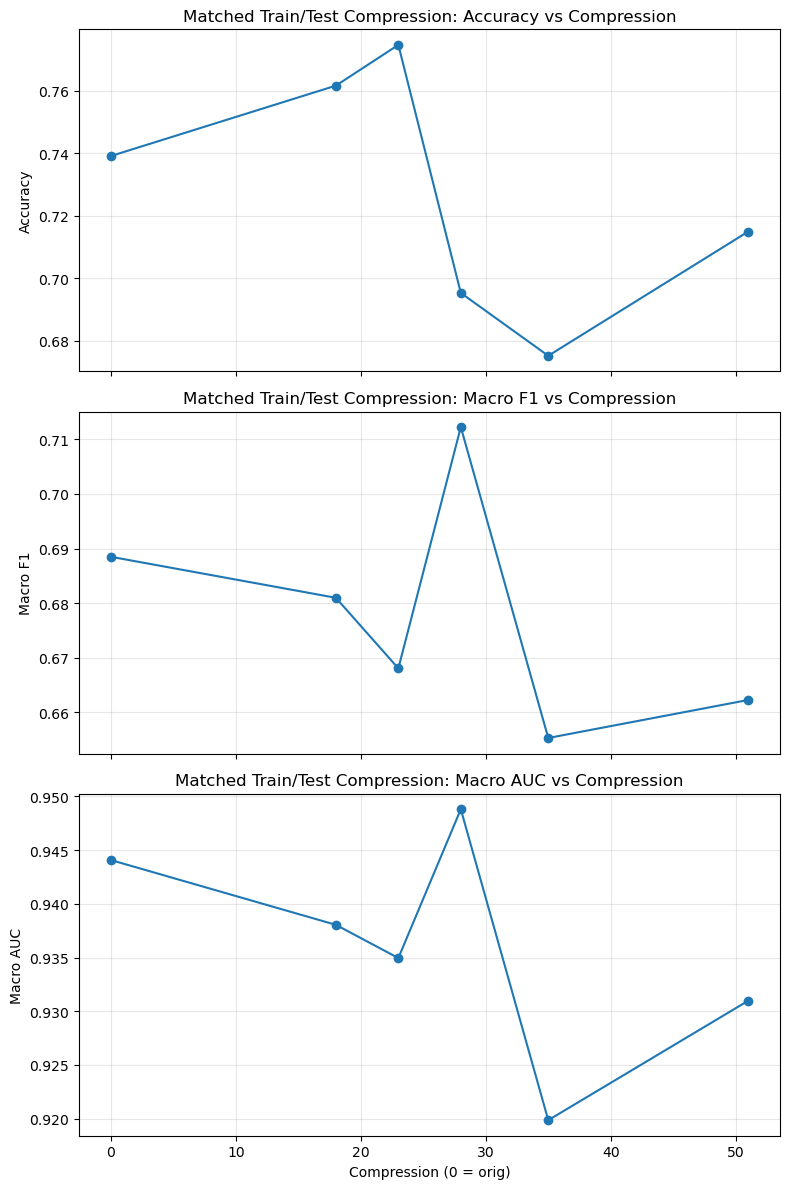

In [19]:
# ============================================================
# 19. Diagonal plots
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

axes[0].plot(diagonal_df["x"], diagonal_df["accuracy"], marker="o")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Matched Train/Test Compression: Accuracy vs Compression")
axes[0].grid(True, alpha=0.3)

axes[1].plot(diagonal_df["x"], diagonal_df["f1_macro"], marker="o")
axes[1].set_ylabel("Macro F1")
axes[1].set_title("Matched Train/Test Compression: Macro F1 vs Compression")
axes[1].grid(True, alpha=0.3)

axes[2].plot(diagonal_df["x"], diagonal_df["auc_macro_ovr"], marker="o")
axes[2].set_ylabel("Macro AUC")
axes[2].set_xlabel("Compression (0 = orig)")
axes[2].set_title("Matched Train/Test Compression: Macro AUC vs Compression")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "diagonal_metrics_vs_compression.png", dpi=200)
plt.show()

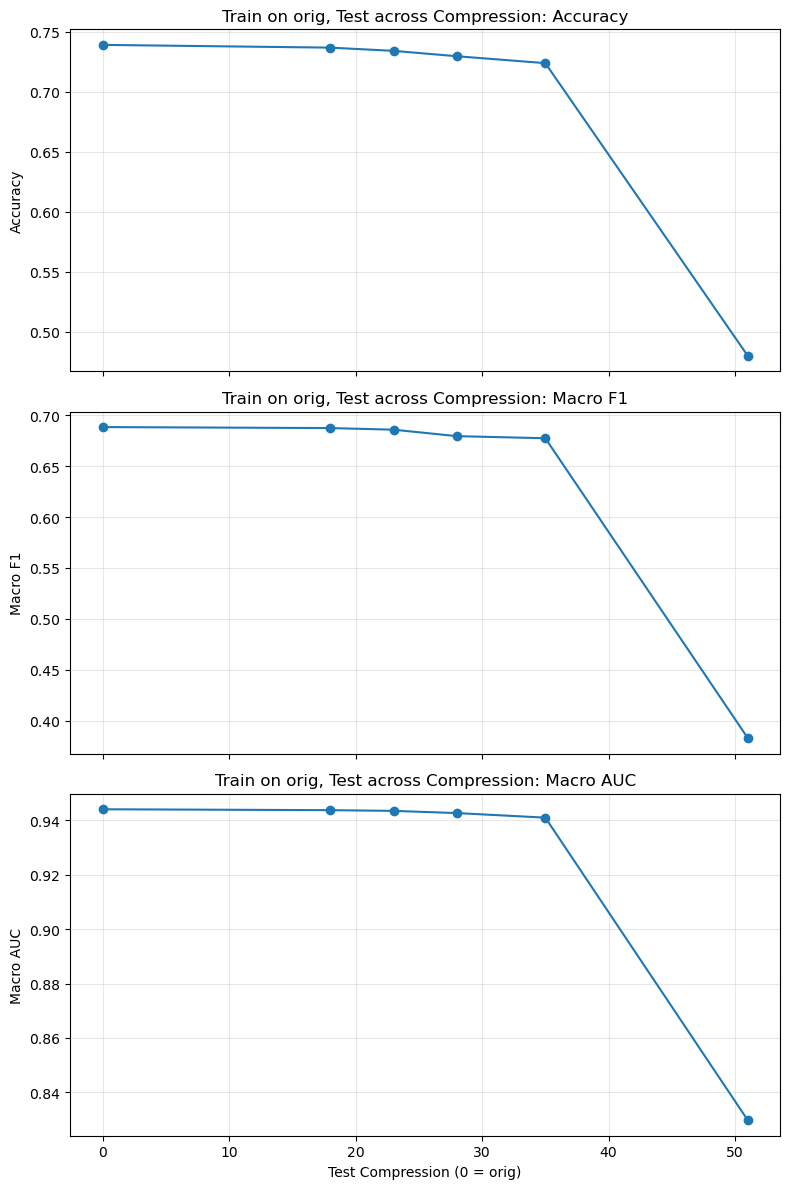

In [20]:
# ============================================================
# 20. Orig-trained curves
# ============================================================
orig_row_df = results_df[results_df["train_level"] == "orig"].copy()
orig_row_df["x"] = orig_row_df["test_level"].map(LEVEL_TO_X)
orig_row_df = orig_row_df.sort_values("x").reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

axes[0].plot(orig_row_df["x"], orig_row_df["accuracy"], marker="o")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Train on orig, Test across Compression: Accuracy")
axes[0].grid(True, alpha=0.3)

axes[1].plot(orig_row_df["x"], orig_row_df["f1_macro"], marker="o")
axes[1].set_ylabel("Macro F1")
axes[1].set_title("Train on orig, Test across Compression: Macro F1")
axes[1].grid(True, alpha=0.3)

axes[2].plot(orig_row_df["x"], orig_row_df["auc_macro_ovr"], marker="o")
axes[2].set_ylabel("Macro AUC")
axes[2].set_xlabel("Test Compression (0 = orig)")
axes[2].set_title("Train on orig, Test across Compression: Macro AUC")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "orig_trained_metrics_vs_test_compression.png", dpi=200)
plt.show()

In [21]:
# ============================================================
# 21. Build per-phase results table
# ============================================================
phase_rows = []
for (train_level, test_level), m in all_results.items():
    for phase_name, phase_f1 in m["per_class_f1"].items():
        phase_rows.append({
            "train_level": train_level,
            "test_level": test_level,
            "phase_name": phase_name,
            "phase_f1": phase_f1,
            "x": LEVEL_TO_X[test_level],
        })

phase_df = pd.DataFrame(phase_rows)
phase_df.to_csv(METRICS_DIR / "per_phase_f1_cross_compression.csv", index=False)
phase_df.head()

,train_level,test_level,phase_name,phase_f1,x
0,orig,orig,Preparation,0.512422,0
1,orig,orig,CalotTriangleDissection,0.767356,0
2,orig,orig,ClippingCutting,0.765680,0
3,orig,orig,GallbladderDissection,0.744294,0
4,orig,orig,GallbladderPackaging,0.698644,0


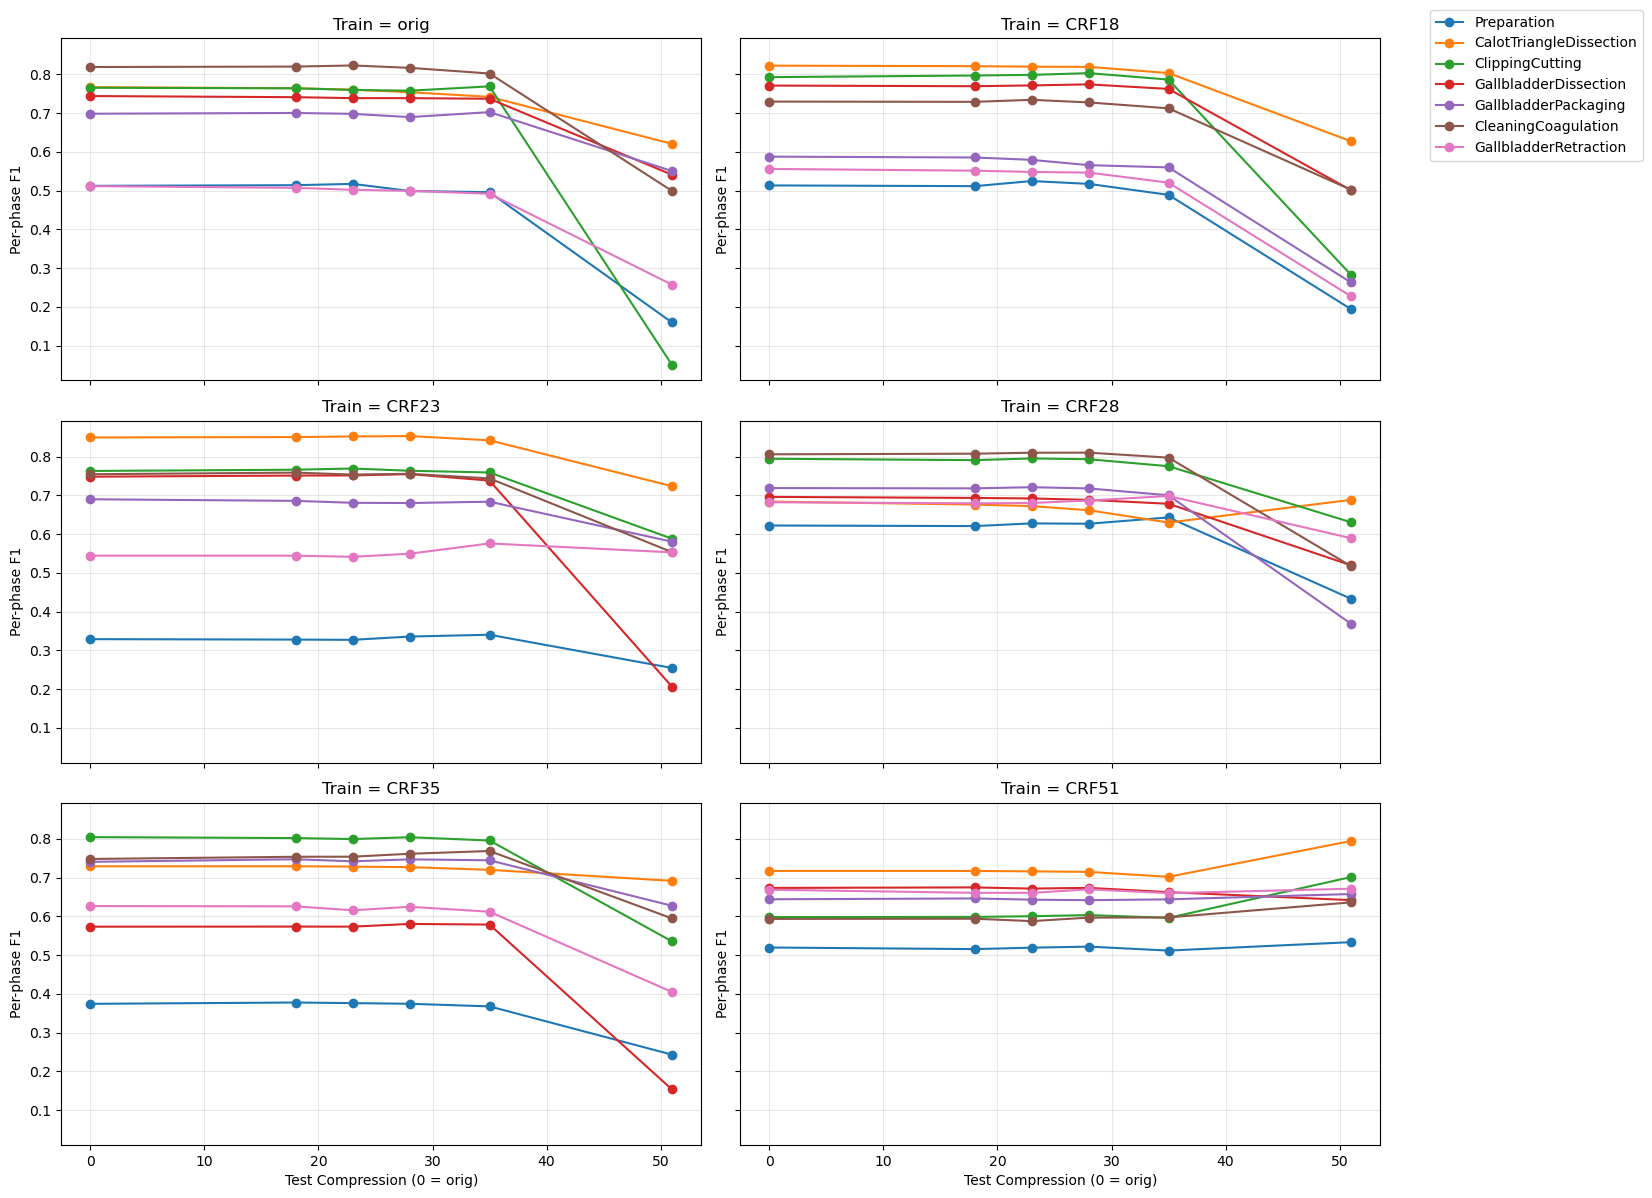

In [22]:
# ============================================================
# 22. Per-phase stacked plot
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True, sharey=True)
axes = axes.flatten()

for ax, train_level in zip(axes, LEVELS):
    subset = phase_df[phase_df["train_level"] == train_level].copy()

    for phase_name in PHASE_MAP.keys():
        s = subset[subset["phase_name"] == phase_name].sort_values("x")
        ax.plot(s["x"], s["phase_f1"], marker="o", label=phase_name)

    ax.set_title(f"Train = {train_level}")
    ax.set_ylabel("Per-phase F1")
    ax.grid(True, alpha=0.3)

for ax in axes[-2:]:
    ax.set_xlabel("Test Compression (0 = orig)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "stacked_per_phase_f1_vs_test_compression.png", dpi=200)
plt.show()

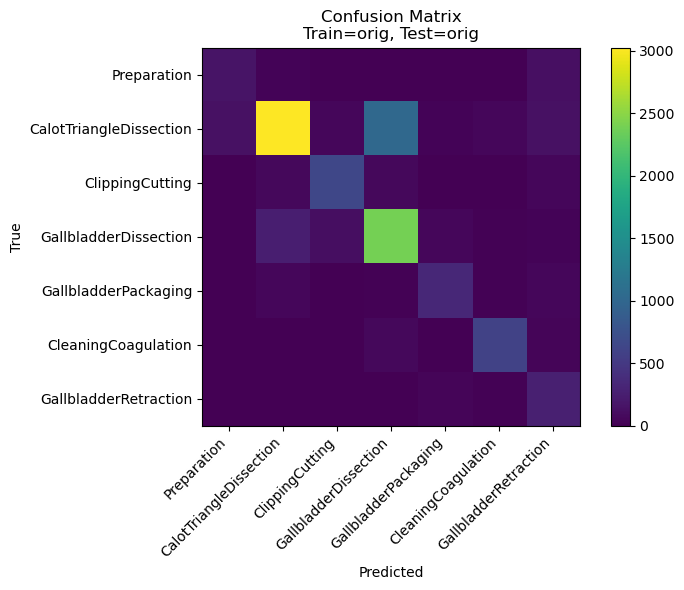

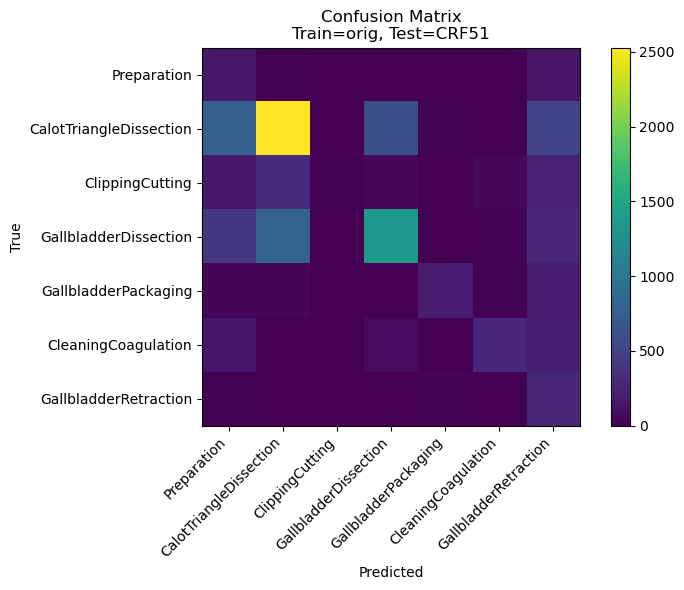

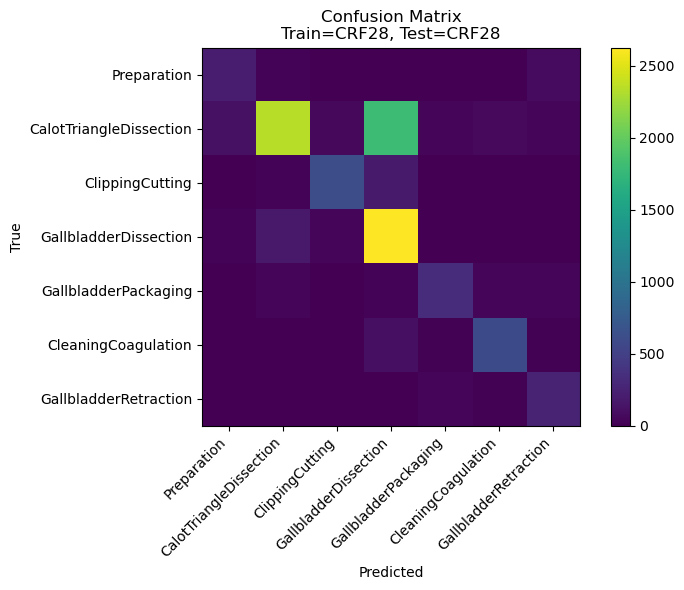

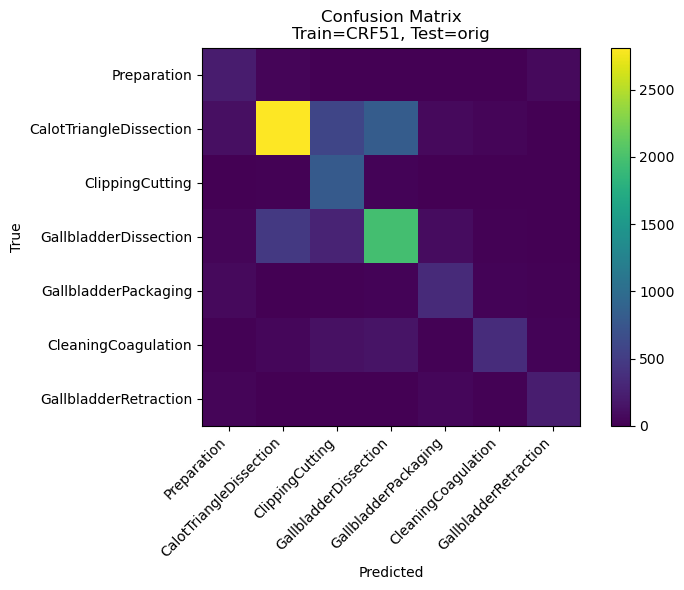

In [23]:
# ============================================================
# 23. Confusion matrix helper
# ============================================================
def plot_confusion_for_pair(train_level, test_level):
    pred_df = all_pred_tables[(train_level, test_level)]
    y_true = pred_df["y_true"].values
    y_pred = pred_df["y_pred"].values

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix\nTrain={train_level}, Test={test_level}")
    plt.colorbar()

    ticks = np.arange(NUM_CLASSES)
    names = [ID_TO_PHASE[i] for i in range(NUM_CLASSES)]
    plt.xticks(ticks, names, rotation=45, ha="right")
    plt.yticks(ticks, names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"confusion_train_{train_level}__test_{test_level}.png", dpi=200)
    plt.show()

selected_pairs = [
    ("orig", "orig"),
    ("orig", "CRF51"),
    ("CRF28", "CRF28"),
    ("CRF51", "orig"),
]

for pair in selected_pairs:
    plot_confusion_for_pair(*pair)

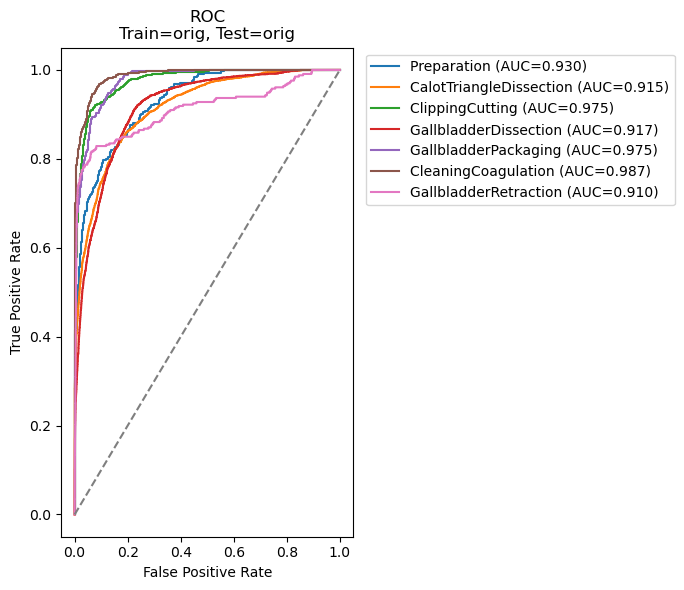

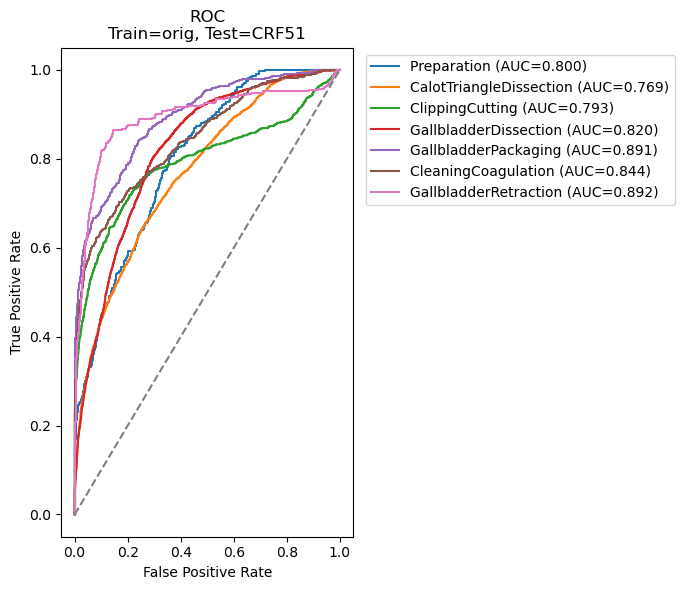

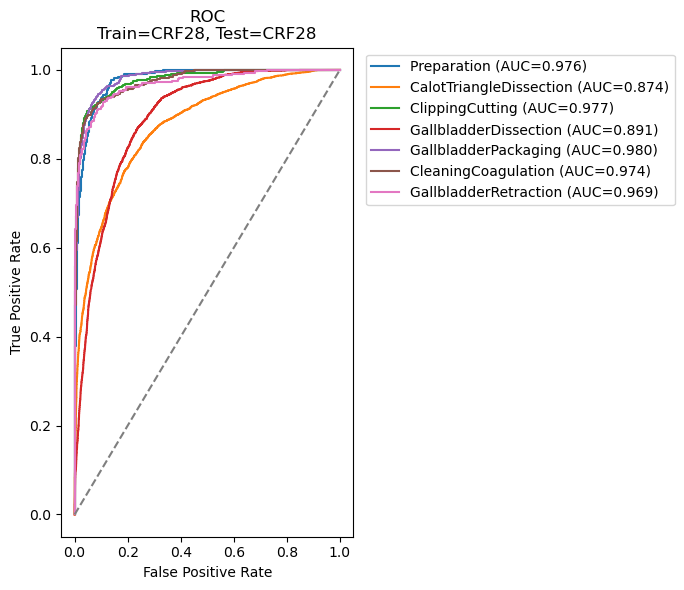

In [24]:
# ============================================================
# 24. ROC helper
# ============================================================
def plot_roc_for_pair(train_level, test_level):
    pred_df = all_pred_tables[(train_level, test_level)]
    y_true = pred_df["y_true"].values
    y_prob = pred_df[[f"prob_{ID_TO_PHASE[i]}" for i in range(NUM_CLASSES)]].values
    y_true_oh = np.eye(NUM_CLASSES)[y_true]

    plt.figure(figsize=(7, 6))

    for c in range(NUM_CLASSES):
        try:
            fpr, tpr, _ = roc_curve(y_true_oh[:, c], y_prob[:, c])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{ID_TO_PHASE[c]} (AUC={roc_auc:.3f})")
        except Exception:
            pass

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC\nTrain={train_level}, Test={test_level}")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"roc_train_{train_level}__test_{test_level}.png", dpi=200)
    plt.show()

for pair in [("orig", "orig"), ("orig", "CRF51"), ("CRF28", "CRF28")]:
    plot_roc_for_pair(*pair)

## Grad-CAM on the last frame of each clip

In [25]:
# ============================================================
# 25. Sequence Grad-CAM
# ============================================================
class SequenceGradCAM:
    def __init__(self, model, target_layer, clip_len=CLIP_LEN):
        self.model = model
        self.target_layer = target_layer
        self.clip_len = clip_len
        self.activations = None
        self.gradients = None
        self.handles = []

        self.handles.append(target_layer.register_forward_hook(self._forward_hook))
        self.handles.append(target_layer.register_full_backward_hook(self._backward_hook))

    def _forward_hook(self, module, inp, out):
        self.activations = out.detach()

    def _backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def remove(self):
        for h in self.handles:
            h.remove()

    def __call__(self, x, class_idx=None):
        # x: [1, T, C, H, W]
        self.model.eval()
        logits = self.model(x)

        if class_idx is None:
            class_idx = int(torch.argmax(logits, dim=1).item())

        score = logits[:, class_idx]
        self.model.zero_grad()
        score.backward(retain_graph=True)

        # activations/grads came from flattened B*T
        acts = self.activations      # [B*T, C, H, W]
        grads = self.gradients       # [B*T, C, H, W]

        B = x.shape[0]
        T = x.shape[1]
        C = acts.shape[1]
        H = acts.shape[2]
        W = acts.shape[3]

        acts = acts.view(B, T, C, H, W)
        grads = grads.view(B, T, C, H, W)

        # use the last frame in the clip
        acts_last = acts[0, -1]
        grads_last = grads[0, -1]

        weights = grads_last.mean(dim=(1, 2))

        cam = torch.zeros(acts_last.shape[1:], device=acts_last.device)
        for c, w in enumerate(weights):
            cam += w * acts_last[c]

        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.detach().cpu().numpy(), class_idx

In [26]:
# ============================================================
# 25. Sequence Grad-CAM
# ============================================================
class SequenceGradCAM:
    def __init__(self, model, target_layer, clip_len=CLIP_LEN):
        self.model = model
        self.target_layer = target_layer
        self.clip_len = clip_len
        self.activations = None
        self.gradients = None
        self.handles = []

        self.handles.append(target_layer.register_forward_hook(self._forward_hook))
        self.handles.append(target_layer.register_full_backward_hook(self._backward_hook))

    def _forward_hook(self, module, inp, out):
        self.activations = out.detach()

    def _backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def remove(self):
        for h in self.handles:
            h.remove()

    def __call__(self, x, class_idx=None):
        # x: [1, T, C, H, W]
        self.model.eval()
        logits = self.model(x)

        if class_idx is None:
            class_idx = int(torch.argmax(logits, dim=1).item())

        score = logits[:, class_idx]
        self.model.zero_grad()
        score.backward(retain_graph=True)

        # activations/grads came from flattened B*T
        acts = self.activations      # [B*T, C, H, W]
        grads = self.gradients       # [B*T, C, H, W]

        B = x.shape[0]
        T = x.shape[1]
        C = acts.shape[1]
        H = acts.shape[2]
        W = acts.shape[3]

        acts = acts.view(B, T, C, H, W)
        grads = grads.view(B, T, C, H, W)

        # use the last frame in the clip
        acts_last = acts[0, -1]
        grads_last = grads[0, -1]

        weights = grads_last.mean(dim=(1, 2))

        cam = torch.zeros(acts_last.shape[1:], device=acts_last.device)
        for c, w in enumerate(weights):
            cam += w * acts_last[c]

        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.detach().cpu().numpy(), class_idx

In [27]:
# ============================================================
# 27. Load one trained model for Grad-CAM
# ============================================================
GRADCAM_TRAIN_LEVEL = "orig"

gradcam_model = ResNet18LSTM().to(DEVICE)
gradcam_ckpt = torch.load(CHECKPOINT_DIR / f"best_resnet18_lstm_train_{GRADCAM_TRAIN_LEVEL}.pth", map_location=DEVICE)
gradcam_model.load_state_dict(gradcam_ckpt["model_state_dict"])
gradcam_model.eval()

gradcam = SequenceGradCAM(gradcam_model, gradcam_model.encoder[-1], clip_len=CLIP_LEN)

print("Loaded Grad-CAM model trained on:", GRADCAM_TRAIN_LEVEL)

Loaded Grad-CAM model trained on: orig


In [28]:
# ============================================================
# 28. Grad-CAM comparison function
# ============================================================
def show_gradcam_comparison(train_level, video, center_second_idx, test_levels=("orig", "CRF18", "CRF28", "CRF51"), use_pred_class=True):
    n = len(test_levels)
    plt.figure(figsize=(4 * n, 8))

    for i, test_level in enumerate(test_levels, start=1):
        row = get_prediction_row(train_level, test_level, video, center_second_idx)
        if row is None:
            continue

        pil_img, clip = load_sequence_clip_from_prediction_row(row, test_level)
        class_idx = int(row["y_pred"]) if use_pred_class else int(row["y_true"])
        cam, used_class = gradcam(clip, class_idx=class_idx)

        raw_img = np.array(pil_img.resize((IMG_SIZE, IMG_SIZE)))

        plt.subplot(2, n, i)
        plt.imshow(raw_img)
        plt.axis("off")
        plt.title(f"Test={test_level}\nTrue={row['y_true_name']}\nPred={row['y_pred_name']}")

        plt.subplot(2, n, i + n)
        plt.imshow(raw_img)
        plt.imshow(cam, alpha=0.4)
        plt.axis("off")
        plt.title(f"Grad-CAM ({ID_TO_PHASE[used_class]})")

    plt.suptitle(f"Train={train_level} | {video} | center_second_idx={center_second_idx}")
    plt.tight_layout()

    save_path = GRADCAM_DIR / f"gradcam_train_{train_level}__{video}_sec{center_second_idx}.png"
    plt.savefig(save_path, dpi=200)
    plt.show()
    print("Saved:", save_path)

In [29]:
# ============================================================
# 29. Pick candidate orig-orig correct examples
# ============================================================
orig_orig_correct = all_pred_tables[("orig", "orig")].copy()
orig_orig_correct = orig_orig_correct[orig_orig_correct["y_true"] == orig_orig_correct["y_pred"]]

orig_orig_correct[["video", "center_second_idx", "y_true_name", "y_pred_name"]].head(20)

,video,center_second_idx,y_true_name,y_pred_name
2,video16,tensor(9),Preparation,Preparation
7,video16,tensor(14),Preparation,Preparation
8,video16,tensor(15),Preparation,Preparation
10,video16,tensor(17),Preparation,Preparation
12,video16,tensor(19),Preparation,Preparation
13,video16,tensor(20),Preparation,Preparation
14,video16,tensor(21),Preparation,Preparation
15,video16,tensor(22),Preparation,Preparation
16,video16,tensor(23),Preparation,Preparation
17,video16,tensor(24),Preparation,Preparation


In [30]:
# ============================================================
# 30. Example Grad-CAM call
# ============================================================
# Replace with a real example from the table above
# show_gradcam_comparison(train_level="orig", video="video16", center_second_idx=100)